# Cell 1 — Install

In [1]:
!pip install -q -U transformers peft datasets accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.0 MB/s eta 0:00:00


# Cell 2 — Imports + GPU

In [2]:
import torch
import os
import random
import numpy as np

from PIL import Image
from datasets import load_dataset
from transformers import (
    AutoProcessor,
    Florence2ForConditionalGeneration
)

from peft import LoraConfig, get_peft_model

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


# Cell 3 — Load Florence-2

In [3]:
MODEL_ID = "florence-community/Florence-2-base"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = Florence2ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

model = model.to(device)

print("Model loaded!")

processor_config.json:   0%|          | 0.00/2.26k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/198k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  463MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/665 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

Model loaded!


# Cell 4 — Load Food-101

In [4]:
import time
from datasets import load_dataset

for attempt in range(5):
    try:
        food101 = load_dataset("ethz/food101")
        fruits_veg = load_dataset("Nattakarn/fruit-and-vegetable-image-recognition")
        print("تم التحميل بنجاح!")
        break
    except Exception as e:
        print(f"محاولة {attempt+1} فشلت، بنعيد بعد 30 ثانية...")
        time.sleep(30)

README.md:   0%|          | 0.00/16.4k [00:00<?, ?B/s]

data/train-00000-of-00008.parquet: reconstructing file:   0%|          |  0.00B /  490MB            

data/train-00000-of-00008.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00008.parquet: reconstructing file:   0%|          |  0.00B /  464MB            

data/train-00001-of-00008.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  292MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2492 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/623 [00:00<?, ? examples/s]

تم التحميل بنجاح!


# cell 5 - labels

In [5]:
food_labels = food101["train"].features["label"].names
fruit_labels = fruits_veg["train"].features["label"].names

print("Food-101 classes:", len(food_labels))
print("Fruits/Veg classes:", len(fruit_labels))

Food-101 classes: 101
Fruits/Veg classes: 36


# Cell 6 — 200 images for each label

In [8]:
NUM_IMAGES_PER_CLASS_FOOD = 100
NUM_IMAGES_PER_CLASS_FRUITS = 60

# Cell 7 — create dataset for test

In [9]:
import random

def select_balanced(dataset, label_names, num_per_class):
    selected_indices = []
    for class_id in range(len(label_names)):
        class_indices = [
            i for i, label in enumerate(dataset["label"])
            if label == class_id
        ]
        random.seed(42)
        n = min(num_per_class, len(class_indices))
        selected = random.sample(class_indices, n)
        selected_indices.extend(selected)
    return dataset.select(selected_indices)

food_train = select_balanced(food101["train"], food_labels, NUM_IMAGES_PER_CLASS_FOOD)
fruits_train = select_balanced(fruits_veg["train"], fruit_labels, NUM_IMAGES_PER_CLASS_FRUITS)

print("Food subset:", food_train)
print("Fruits subset:", fruits_train)

Food subset: Dataset({
    features: ['image', 'label'],
    num_rows: 10100
})
Fruits subset: Dataset({
    features: ['image', 'label'],
    num_rows: 2132
})


# Cell 8 — label to caption

In [10]:
from datasets import concatenate_datasets

def make_caption_fn(label_names):
    def create_caption(example):
        food_name = label_names[example["label"]]
        food_name = food_name.replace("_", " ")
        caption = f"This is {food_name}."
        return {"caption": caption}
    return create_caption

food_train = food_train.map(make_caption_fn(food_labels))
fruits_train = fruits_train.map(make_caption_fn(fruit_labels))

food_train = food_train.remove_columns(
    [c for c in food_train.column_names if c not in ("image", "caption")]
)
fruits_train = fruits_train.remove_columns(
    [c for c in fruits_train.column_names if c not in ("image", "caption")]
)

small_train = concatenate_datasets([food_train, fruits_train]).shuffle(seed=42)

print(small_train)
print(small_train[0])

Map:   0%|          | 0/10100 [00:00<?, ? examples/s]

Map:   0%|          | 0/2132 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'caption'],
    num_rows: 12232
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x384 at 0x790D74E13380>, 'caption': 'This is grilled salmon.'}


# Cell 9 — Data Aggregator

In [11]:
TASK_PROMPT = "<FOOD_CAPTION>"

def collate_fn(batch):

    images = [
        item["image"].convert("RGB")
        for item in batch
    ]

    captions = [
        item["caption"]
        for item in batch
    ]

    prompts = [
        TASK_PROMPT
        for _ in batch
    ]

    inputs = processor(
        text=prompts,
        images=images,
        padding=True,
        return_tensors="pt"
    )

    labels_batch = processor.tokenizer(
        captions,
        padding=True,
        return_tensors="pt"
    ).input_ids

    labels_batch[
        labels_batch == processor.tokenizer.pad_token_id
    ] = -100

    inputs["labels"] = labels_batch

    return inputs

# Cell 10 — LoRA

low rank adaptation

In [12]:
!pip install -q -U torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 58.5 MB/s eta 0:00:00


In [13]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "out_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM"
)

model = get_peft_model(
    model,
    lora_config
)

model.print_trainable_parameters()

trainable params: 1,769,472 || all params: 233,213,440 || trainable%: 0.7587


# Cell 11 — Training Arguments

In [14]:
from transformers import TrainingArguments

In [15]:
training_args = TrainingArguments(
    output_dir="/content/florence2-food101-lora",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-4,
    fp16=True,
    logging_steps=20,
    save_steps=500,
    save_total_limit=1,
    remove_unused_columns=False,
    report_to="none",
    dataloader_num_workers=2
)

# Cell 12 — Trainer

In [16]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    data_collator=collate_fn
)

In [17]:
trainer.train()

Step,Training Loss
20,2.522623
40,0.603882
60,0.486860
80,0.407957
100,0.377344
120,0.357509
140,0.319224
160,0.294018
180,0.255260
200,0.264553


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


TrainOutput(global_step=765, training_loss=0.2937699587516535, metrics={'train_runtime': 972.9233, 'train_samples_per_second': 12.572, 'train_steps_per_second': 0.786, 'total_flos': 8264637187276800.0, 'train_loss': 0.2937699587516535, 'epoch': 1.0})

# cell 13 - test on images

Saving 1583851621211.webp to 1583851621211.webp


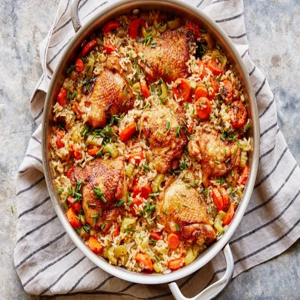

Classification:
This is chicken and rice.

Description:
The image shows a large casserole dish filled with fried rice. The rice is golden brown and appears to be
seasoned with herbs and spices. There are several pieces of chicken scattered throughout the dish. The dish is garnished with
red and orange bell peppers. The background is a light blue color, and there is a striped napkin on the
side.


In [18]:
# ==========================================
# upload an image and test it
# ==========================================
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

def run_task(prompt, max_tokens):
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]

classification = run_task("<FOOD_CAPTION>", 30)
description = run_task("<MORE_DETAILED_CAPTION>", 150)

words = description.split()
formatted_description = "\n".join(
    " ".join(words[i:i+20]) for i in range(0, len(words), 20)
)

print("Classification:")
print(classification)
print("\nDescription:")
print(formatted_description)

Saving download (3).jfif to download (3).jfif


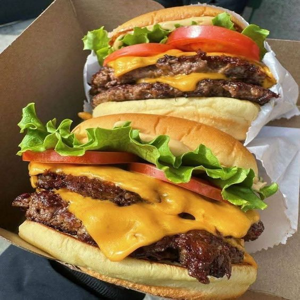

Classification:
This is hamburger.

Description:
The image shows two hamburgers in a cardboard box. The burgers are made with beef patty, lettuce, tomato, and cheese.
The beef is cooked to a golden brown and appears to be seasoned with herbs and spices. The cheese is
melted and oozing out of the sides. The hamburger is garnished with fresh lettuce and tomato.


In [19]:
# ==========================================
# upload an image and test it
# ==========================================
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

def run_task(prompt, max_tokens):
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]

classification = run_task("<FOOD_CAPTION>", 30)
description = run_task("<MORE_DETAILED_CAPTION>", 150)

words = description.split()
formatted_description = "\n".join(
    " ".join(words[i:i+20]) for i in range(0, len(words), 20)
)

print("Classification:")
print(classification)
print("\nDescription:")
print(formatted_description)

Saving easy-fried-rice-4.jpg to easy-fried-rice-4.jpg


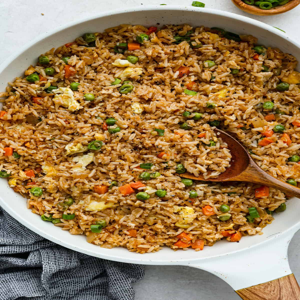

Classification:
This is fried rice.

Description:
The image shows a large white casserole dish filled with fried rice. The fried rice is golden brown and appears
to be seasoned with herbs and spices. There are small pieces of vegetables scattered throughout the dish. A wooden spoon
is resting on the side of the dish, ready to be used. The dish is garnished with chopped green onions.
The background is a white countertop with a gray and white checkered napkin.


In [20]:
# ==========================================
# upload an image and test it
# ==========================================
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

def run_task(prompt, max_tokens):
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]

classification = run_task("<FOOD_CAPTION>", 30)
description = run_task("<MORE_DETAILED_CAPTION>", 150)

words = description.split()
formatted_description = "\n".join(
    " ".join(words[i:i+20]) for i in range(0, len(words), 20)
)

print("Classification:")
print(classification)
print("\nDescription:")
print(formatted_description)

Saving Delicious Pizza.jfif to Delicious Pizza.jfif


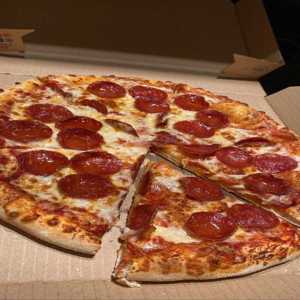

Classification:
This is pizza.

Description:
The image is of a pepperoni pizza. The pizza is in a cardboard box. The crust is golden brown and
the cheese is melted and bubbly. The pepperoni is arranged in a circular pattern on top of the pizza. There
are two slices of the same pizza, one on each side.


In [21]:
# ==========================================
# upload an image and test it
# ==========================================
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

def run_task(prompt, max_tokens):
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]

classification = run_task("<FOOD_CAPTION>", 30)
description = run_task("<MORE_DETAILED_CAPTION>", 150)

words = description.split()
formatted_description = "\n".join(
    " ".join(words[i:i+20]) for i in range(0, len(words), 20)
)

print("Classification:")
print(classification)
print("\nDescription:")
print(formatted_description)

Saving images.jfif to images.jfif


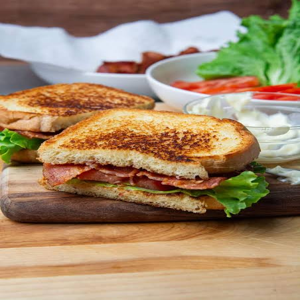

Classification:
This is grilled cheese sandwich.

Description:
The image shows a grilled cheese sandwich on a wooden cutting board. The sandwich is made with two slices of
toasted bread, filled with bacon and lettuce. The bread is golden brown and appears to be crispy on the outside.
There is a small bowl of salad on the right side of the cutting board, and a plate of chips
on the left side. The background is blurred, but it seems to be a kitchen countertop.


In [22]:
# ==========================================
# upload an image and test it
# ==========================================
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

def run_task(prompt, max_tokens):
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]

classification = run_task("<FOOD_CAPTION>", 30)
description = run_task("<MORE_DETAILED_CAPTION>", 150)

words = description.split()
formatted_description = "\n".join(
    " ".join(words[i:i+20]) for i in range(0, len(words), 20)
)

print("Classification:")
print(classification)
print("\nDescription:")
print(formatted_description)

Saving #pastafoodrecipes #pasta #cooking #yummy_.jfif to #pastafoodrecipes #pasta #cooking #yummy_.jfif


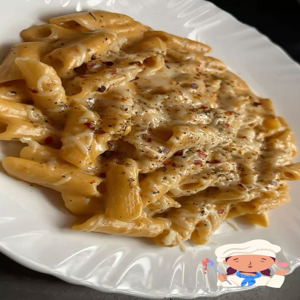

Classification:
This is penne pasta.

Description:
The image shows a plate of macaroni and cheese. The pasta is cooked al dente and is covered in a
creamy sauce. The sauce is a light yellow color and appears to be thick and creamy. There are small bits
of herbs scattered throughout the dish. The plate is white and has a scalloped edge.


In [38]:
# ==========================================
# upload an image and test it
# ==========================================
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

def run_task(prompt, max_tokens):
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]

classification = run_task("<FOOD_CAPTION>", 30)
description = run_task("<MORE_DETAILED_CAPTION>", 150)

words = description.split()
formatted_description = "\n".join(
    " ".join(words[i:i+20]) for i in range(0, len(words), 20)
)

print("Classification:")
print(classification)
print("\nDescription:")
print(formatted_description)

Saving The-Best-Homemade-Hummus-Recipe-1200.jpg to The-Best-Homemade-Hummus-Recipe-1200.jpg


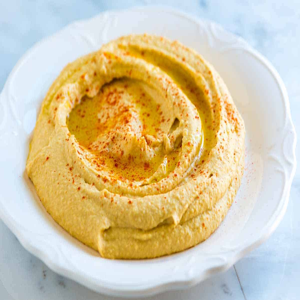

Classification:
This is hummus.

Description:
The image shows a bowl of hummus. The hummus is round and golden brown in color. It is spread out
in a circular pattern on the plate. The plate is white and has a textured surface. The background is a
light blue color.


In [41]:
# ==========================================
# upload an image and test it
# ==========================================
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

def run_task(prompt, max_tokens):
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]

classification = run_task("<FOOD_CAPTION>", 30)
description = run_task("<MORE_DETAILED_CAPTION>", 150)

words = description.split()
formatted_description = "\n".join(
    " ".join(words[i:i+20]) for i in range(0, len(words), 20)
)

print("Classification:")
print(classification)
print("\nDescription:")
print(formatted_description)

Saving images (2).webp to images (2).webp


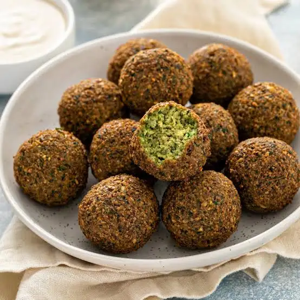

Classification:
This is falafel.

Description:
The image shows a plate of falafel. The falafels are round and golden brown in color. They are covered in
a mixture of herbs and spices, giving them a savory flavor. In the center of the plate, there is a
small bowl of dipping sauce. The plate is sitting on a white tablecloth.


In [43]:
# ==========================================
# upload an image and test it
# ==========================================
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

def run_task(prompt, max_tokens):
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]

classification = run_task("<FOOD_CAPTION>", 30)
description = run_task("<MORE_DETAILED_CAPTION>", 150)

words = description.split()
formatted_description = "\n".join(
    " ".join(words[i:i+20]) for i in range(0, len(words), 20)
)

print("Classification:")
print(classification)
print("\nDescription:")
print(formatted_description)